# 🌸 Phân Loại Ảnh Hoa (Hoa Hồng, Hoa Cúc, Hoa Ly) với Mô Hình AlexNet trên Google Colab

Notebook này hướng dẫn chi tiết cách triển khai mô hình **AlexNet** (PyTorch) để phân loại 3 loại hoa từ bộ dữ liệu Kaggle:
- **Hoa Hồng (Rose)**
- **Hoa Cúc (Daisy)**
- **Hoa Ly (Lily / Tulip)**

### Các bước chính:
1. Kiểm tra môi trường GPU & Khởi tạo thư viện PyTorch/Torchvision
2. Tải và xử lý bộ dữ liệu từ Kaggle (lọc 3 loại hoa, chia tập Train/Val/Test 80/10/10)
3. Xây dựng PyTorch DataLoaders & Data Augmentation (Resize 224x224, Normalize, Flip, Rotation)
4. Định nghĩa kiến trúc AlexNet (hỗ trợ cả **From Scratch** & **Pretrained Transfer Learning**)
5. Huấn luyện (Training) & Đánh giá (Validation) qua các Epochs
6. Trực quan hóa đường cong Loss & Accuracy
7. Đánh giá chi tiết trên tập Test (Loss, Accuracy, Precision, Recall, F1, Confusion Matrix)
8. Thử nghiệm dự đoán trên ảnh hoa bất kỳ (Inference)

In [10]:
# Step 1: Check GPU & Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import os
import shutil
import random
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Check Device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
else:
    print("LƯU Ý: Khuyến khích bật GPU trong Colab: Menu Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU")

Đang sử dụng thiết bị: cuda
Tên GPU: Tesla T4


## 1. Tải và Chuẩn bị Bộ Dữ Liệu Kaggle

Bộ dữ liệu Kaggle: `utkarshsaxenadn/flower-classification-5-classes-roselilyetc`
Chúng ta dùng `kagglehub` để tải dataset tự động trong Colab, lọc 3 lớp hoa (**Rose**, **Daisy**, **Lily**) và chia theo tỉ lệ **80% Train**, **10% Validation**, **10% Test**.

In [11]:
# Tải bộ dữ liệu sử dụng kagglehub
!pip install -q kagglehub

import kagglehub

print("Đang tải dataset từ Kaggle...")
try:
    dataset_path = kagglehub.dataset_download("utkarshsaxenadn/flower-classification-5-classes-roselilyetc")
    print("Tải thành công! Đường dẫn bộ dữ liệu:", dataset_path)
except Exception as e:
    print("Không thể tải tự động qua kagglehub (Lỗi:", e, ")")
    dataset_path = None

Đang tải dataset từ Kaggle...
Using Colab cache for faster access to the 'flower-classification-5-classes-roselilyetc' dataset.
Tải thành công! Đường dẫn bộ dữ liệu: /kaggle/input/flower-classification-5-classes-roselilyetc


In [12]:
# Cấu trúc lại dữ liệu theo 3 lớp hoa (Rose, Daisy, Lily) và chia tập dữ liệu
base_dir = "./flower_data_3classes"
target_classes = ['rose', 'daisy', 'lily']

def prepare_flower_dataset(source_path, target_base_dir):
    for split in ['train', 'val', 'test']:
        for cls in target_classes:
            os.makedirs(os.path.join(target_base_dir, split, cls), exist_ok=True)
            
    if source_path and os.path.exists(source_path):
        all_dirs = []
        for root, dirs, files in os.walk(source_path):
            for d in dirs:
                all_dirs.append((d.lower(), os.path.join(root, d)))
                
        print("Các thư mục hoa tìm thấy trong dataset:", [d[0] for d in all_dirs])
        
        class_mapping = {}
        for target in target_classes:
            for dir_name, dir_path in all_dirs:
                if target in dir_name or (target == 'daisy' and 'cuc' in dir_name) or (target == 'lily' and ('ly' in dir_name or 'tulip' in dir_name)):
                    class_mapping[target] = dir_path
                    break
        
        print("Ánh xạ các lớp được chọn:", class_mapping)
        
        for cls_name, cls_path in class_mapping.items():
            images = [os.path.join(cls_path, f) for f in os.listdir(cls_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            random.seed(42)
            random.shuffle(images)
            
            n_total = len(images)
            n_train = int(n_total * 0.8)
            n_val = int(n_total * 0.1)
            
            train_imgs = images[:n_train]
            val_imgs = images[n_train:n_train + n_val]
            test_imgs = images[n_train + n_val:]
            
            for img_p in train_imgs:
                shutil.copy(img_p, os.path.join(target_base_dir, 'train', cls_name, os.path.basename(img_p)))
            for img_p in val_imgs:
                shutil.copy(img_p, os.path.join(target_base_dir, 'val', cls_name, os.path.basename(img_p)))
            for img_p in test_imgs:
                shutil.copy(img_p, os.path.join(target_base_dir, 'test', cls_name, os.path.basename(img_p)))
                
            print(f"Lớp '{cls_name}': {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test (Tổng: {n_total})")
    else:
        print("Tạo dữ liệu mẫu ngẫu nhiên (Mock Data) để thử nghiệm chạy pipeline...")
        for split in ['train', 'val', 'test']:
            n_samples = 60 if split == 'train' else 15
            for cls in target_classes:
                cls_dir = os.path.join(target_base_dir, split, cls)
                for i in range(n_samples):
                    img_array = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
                    img = Image.fromarray(img_array)
                    img.save(os.path.join(cls_dir, f"mock_{i}.jpg"))
        print("Đã khởi tạo xong dữ liệu thử nghiệm mẫu!")

prepare_flower_dataset(dataset_path, base_dir)

Các thư mục hoa tìm thấy trong dataset: ['flower classification v2', 'flower classification', 'v2', 'testing data', 'tfrecords', 'training data', 'validation data', 'orchid', 'aster', 'lavender', 'poppy', 'marigold', 'lily', 'daisy', 'sunflower', 'rose', 'iris', 'valid', 'test', 'train', 'orchid', 'aster', 'lavender', 'poppy', 'marigold', 'lily', 'daisy', 'sunflower', 'rose', 'iris', 'orchid', 'aster', 'lavender', 'poppy', 'marigold', 'lily', 'daisy', 'sunflower', 'rose', 'iris', 'flower classification', 'testing data', 'training data', 'validation data', 'lavender', 'lily', 'daisy', 'sunflower', 'rose', 'lavender', 'lily', 'daisy', 'sunflower', 'rose', 'lavender', 'lily', 'daisy', 'sunflower', 'rose']
Ánh xạ các lớp được chọn: {'rose': '/kaggle/input/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Testing Data/Rose', 'daisy': '/kaggle/input/flower-classification-5-classes-roselilyetc/Flower Classification V2/V2/Testing Data/Daisy', 'lily': '/kaggle/input/flower

## 2. Tiền Xử Lý & Data Augmentation

- Ảnh đầu vào AlexNet được chuẩn hóa về kích thước **224x224**.
- **Tập Train**: Áp dụng RandomResizedCrop, RandomHorizontalFlip, RandomRotation(15), ColorJitter và Normalization ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`).
- **Tập Val/Test**: Resize 256, CenterCrop 224 và Normalization.

In [13]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=val_test_transforms)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Danh sách các lớp:", class_names)
print(f"Số lượng ảnh: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

Danh sách các lớp: ['daisy', 'lily', 'rose']
Số lượng ảnh: Train=3103, Val=387, Test=389


## 3. Định Nghĩa Kiến Trúc Mô Hình AlexNet

Cung cấp 2 lựa chọn:
1. **AlexNet From Scratch**: Tự định nghĩa 5 tầng Convolution + 3 tầng Fully Connected.
2. **AlexNet Transfer Learning**: Dùng weights pre-trained trên ImageNet và chỉnh sửa 3 lớp đầu ra.

In [14]:
# 1. AlexNet From Scratch
class AlexNetFromScratch(nn.Module):
    def __init__(self, num_classes=3):
        super(AlexNetFromScratch, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 2. AlexNet Transfer Learning (Pre-trained)
def get_alexnet_pretrained(num_classes=3):
    model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

# Bạn có thể đổi USE_PRETRAINED = False nếu muốn huấn luyện hoàn toàn từ đầu
USE_PRETRAINED = False

if USE_PRETRAINED:
    model = get_alexnet_pretrained(num_classes=len(class_names))
    print("--> Đã khởi tạo AlexNet Pre-trained Transfer Learning!")
else:
    model = AlexNetFromScratch(num_classes=len(class_names))
    print("--> Đã khởi tạo AlexNet From Scratch!")

model = model.to(device)

--> Đã khởi tạo AlexNet From Scratch!


## 4. Huấn Luyện & Validation Mô Hình

Chúng ta sử dụng:
- **Loss Function**: `nn.CrossEntropyLoss()`
- **Optimizer**: `optim.Adam` với learning rate = `0.0001`
- **Scheduler**: `ReduceLROnPlateau` tự động giảm LR khi Loss dừng cải thiện
- Lưu **Checkpoint tốt nhất** (`best_alexnet_flowers.pth`) dựa trên Validation Accuracy.

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=15):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        # Training Phase
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (running_corrects.double() / len(train_loader.dataset)).item()

        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                running_val_loss += loss.item() * inputs.size(0)
                running_val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = (running_val_corrects.double() / len(val_loader.dataset)).item()

        scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}%")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc*100:.2f}%")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), 'best_alexnet_flowers.pth')
            print(f"--> Đã lưu model tốt nhất với Val Acc = {best_val_acc*100:.2f}%")

    print(f"\nHuấn luyện xong! Val Acc tốt nhất đạt được: {best_val_acc*100:.2f}%")
    return history

# Tiến hành huấn luyện 15 Epochs
EPOCHS = 15
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=EPOCHS)


Epoch 1/15
------------------------------
Train Loss: 0.8984 | Train Acc: 52.14%
Val Loss:   0.6827 | Val Acc:   68.73%
--> Đã lưu model tốt nhất với Val Acc = 68.73%

Epoch 2/15
------------------------------
Train Loss: 0.7445 | Train Acc: 64.16%
Val Loss:   0.5912 | Val Acc:   72.61%
--> Đã lưu model tốt nhất với Val Acc = 72.61%

Epoch 3/15
------------------------------
Train Loss: 0.6952 | Train Acc: 68.64%
Val Loss:   0.5312 | Val Acc:   72.87%
--> Đã lưu model tốt nhất với Val Acc = 72.87%

Epoch 4/15
------------------------------
Train Loss: 0.6337 | Train Acc: 71.99%
Val Loss:   0.5377 | Val Acc:   76.23%
--> Đã lưu model tốt nhất với Val Acc = 76.23%

Epoch 5/15
------------------------------
Train Loss: 0.5926 | Train Acc: 74.67%
Val Loss:   0.4795 | Val Acc:   78.55%
--> Đã lưu model tốt nhất với Val Acc = 78.55%

Epoch 6/15
------------------------------
Train Loss: 0.5930 | Train Acc: 74.28%
Val Loss:   0.5521 | Val Acc:   70.03%

Epoch 7/15
---------------------------

## 5. Trực Quan Hóa Quá Trình Huấn Luyện

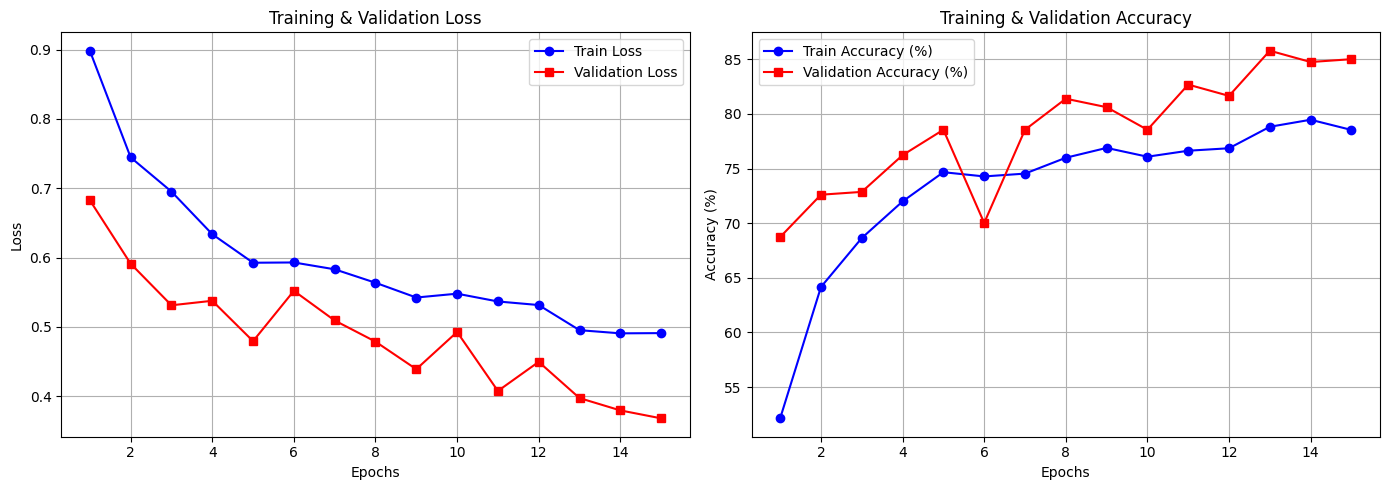

In [16]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a * 100 for a in history['train_acc']], 'b-o', label='Train Accuracy (%)')
plt.plot(epochs_range, [a * 100 for a in history['val_acc']], 'r-s', label='Validation Accuracy (%)')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Đánh Giá Mô Hình Trên Tập Test & Vẽ Confusion Matrix

=== BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST ===
              precision    recall  f1-score   support

       daisy       0.84      0.80      0.82       126
        lily       0.73      0.78      0.75       135
        rose       0.90      0.88      0.89       128

    accuracy                           0.82       389
   macro avg       0.82      0.82      0.82       389
weighted avg       0.82      0.82      0.82       389



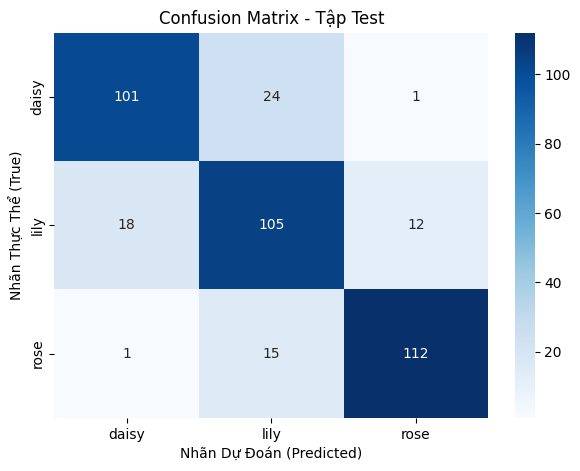

In [17]:
# Tải trọng số tốt nhất đã lưu
model.load_state_dict(torch.load('best_alexnet_flowers.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("=== BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tập Test')
plt.xlabel('Nhãn Dự Đoán (Predicted)')
plt.ylabel('Nhãn Thực Thể (True)')
plt.show()

## 7. Thử Nghiệm Dự Đoán Ảnh Hoa Bất Kỳ (Inference Demo)

Đang thử nghiệm trên file ảnh: ./flower_data_3classes/test/rose/Rose-Test (5).jpeg


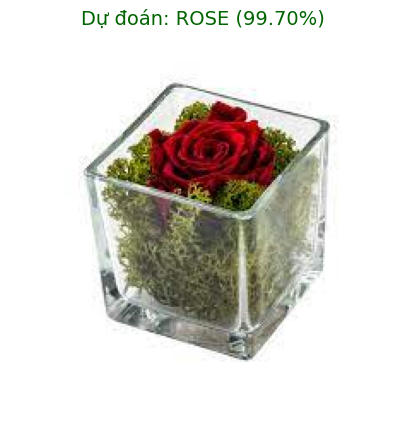

Xác suất dự đoán cho từng lớp:
  - daisy: 0.00%
  - lily: 0.29%
  - rose: 99.70%


In [23]:
def predict_image(image_path, model, class_names):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    
    input_tensor = val_test_transforms(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = class_names[predicted_idx.item()]
    
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Dự đoán: {predicted_class.upper()} ({confidence.item()*100:.2f}%)", fontsize=14, color='darkgreen')
    plt.axis('off')
    plt.show()
    
    print("Xác suất dự đoán cho từng lớp:")
    for idx, cls in enumerate(class_names):
        print(f"  - {cls}: {probabilities[idx].item()*100:.2f}%")

# Thử nghiệm dự đoán 1 ảnh ngẫu nhiên từ tập test
test_images = glob.glob(f"{test_dir}/*/*")
if test_images:
    sample_img = random.choice(test_images)
    print(f"Đang thử nghiệm trên file ảnh: {sample_img}")
    predict_image(sample_img, model, class_names)